In [1]:
# Install required libraries
!pip install xgboost plotly

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
np.random.seed(42)
n = 1200

states = ['UP', 'MH', 'DL', 'RJ', 'KA', 'GJ', 'TN', 'WB', 'MP', 'HR']
causes = ['Education', 'Health', 'Environment', 'Other']
age_groups = ['18-25', '26-35', '36-50', '51+']

df = pd.DataFrame({
    'age_group': np.random.choice(age_groups, n, p=[.25,.35,.25,.15]),
    'state': np.random.choice(states, n),
    'prev_donations': np.random.poisson(2, n),
    'last_gift_amount': np.random.exponential(800, n).astype(int),
    'email_open_rate': np.random.uniform(0, 100, n).round(1),
    'campaigns_participated': np.random.poisson(1.5, n),
    'is_social_follower': np.random.choice([0,1], n, p=[.45,.55]),
    'volunteer_history': np.random.choice([0,1], n, p=[.6,.4]),
    'cause_area': np.random.choice(causes, n),
})

# Create target variable
score = (df.prev_donations * 0.4 +
         df.email_open_rate/100 * 0.25 +
         df.campaigns_participated * 0.2 +
         df.volunteer_history * 0.15)

df['will_repeat_donate'] = (score + np.random.normal(0, .15, n) > 0.6).astype(int)

print("Dataset created!")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()print("=== Dataset Info ===")
print(f"Total donors: {len(df)}")
print(f"Will donate again: {df.will_repeat_donate.sum()} ({df.will_repeat_donate.mean()*100:.1f}%)")
print(f"Won't donate again: {(df.will_repeat_donate==0).sum()} ({(df.will_repeat_donate==0).mean()*100:.1f}%)")

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Stats ===")
df.describe()

Dataset created!
Shape: (1200, 10)

First 5 rows:


,age_group,state,prev_donations,last_gift_amount,email_open_rate,campaigns_participated,is_social_follower,volunteer_history,cause_area,will_repeat_donate
0,26-35,TN,2,486,31.0,1,1,0,Other,1
1,51+,UP,3,1772,81.2,2,1,1,Health,1
2,36-50,GJ,2,674,86.7,1,0,1,Education,1
3,26-35,DL,1,1428,67.3,2,0,1,Education,1
4,18-25,HR,2,3825,4.7,1,1,1,Other,1


In [4]:
print("=== Dataset Info ===")
print(f"Total donors: {len(df)}")
print(f"Will donate again: {df.will_repeat_donate.sum()} ({df.will_repeat_donate.mean()*100:.1f}%)")
print(f"Won't donate again: {(df.will_repeat_donate==0).sum()} ({(df.will_repeat_donate==0).mean()*100:.1f}%)")

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Stats ===")
df.describe()

=== Dataset Info ===
Total donors: 1200
Will donate again: 1029 (85.8%)
Won't donate again: 171 (14.2%)

=== Missing Values ===
age_group                 0
state                     0
prev_donations            0
last_gift_amount          0
email_open_rate           0
campaigns_participated    0
is_social_follower        0
volunteer_history         0
cause_area                0
will_repeat_donate        0
dtype: int64

=== Basic Stats ===


,prev_donations,last_gift_amount,email_open_rate,campaigns_participated,is_social_follower,volunteer_history,will_repeat_donate
count,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,1.99500,803.577500,48.736000,1.491667,0.535833,0.391667,0.857500
std,1.37473,819.903457,28.496234,1.192805,0.498922,0.488326,0.349708
min,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.00000,222.750000,24.175000,1.000000,0.000000,0.000000,1.000000
50%,2.00000,536.000000,48.600000,1.000000,1.000000,0.000000,1.000000
75%,3.00000,1148.000000,72.000000,2.000000,1.000000,1.000000,1.000000
max,7.00000,6020.000000,99.900000,7.000000,1.000000,1.000000,1.000000


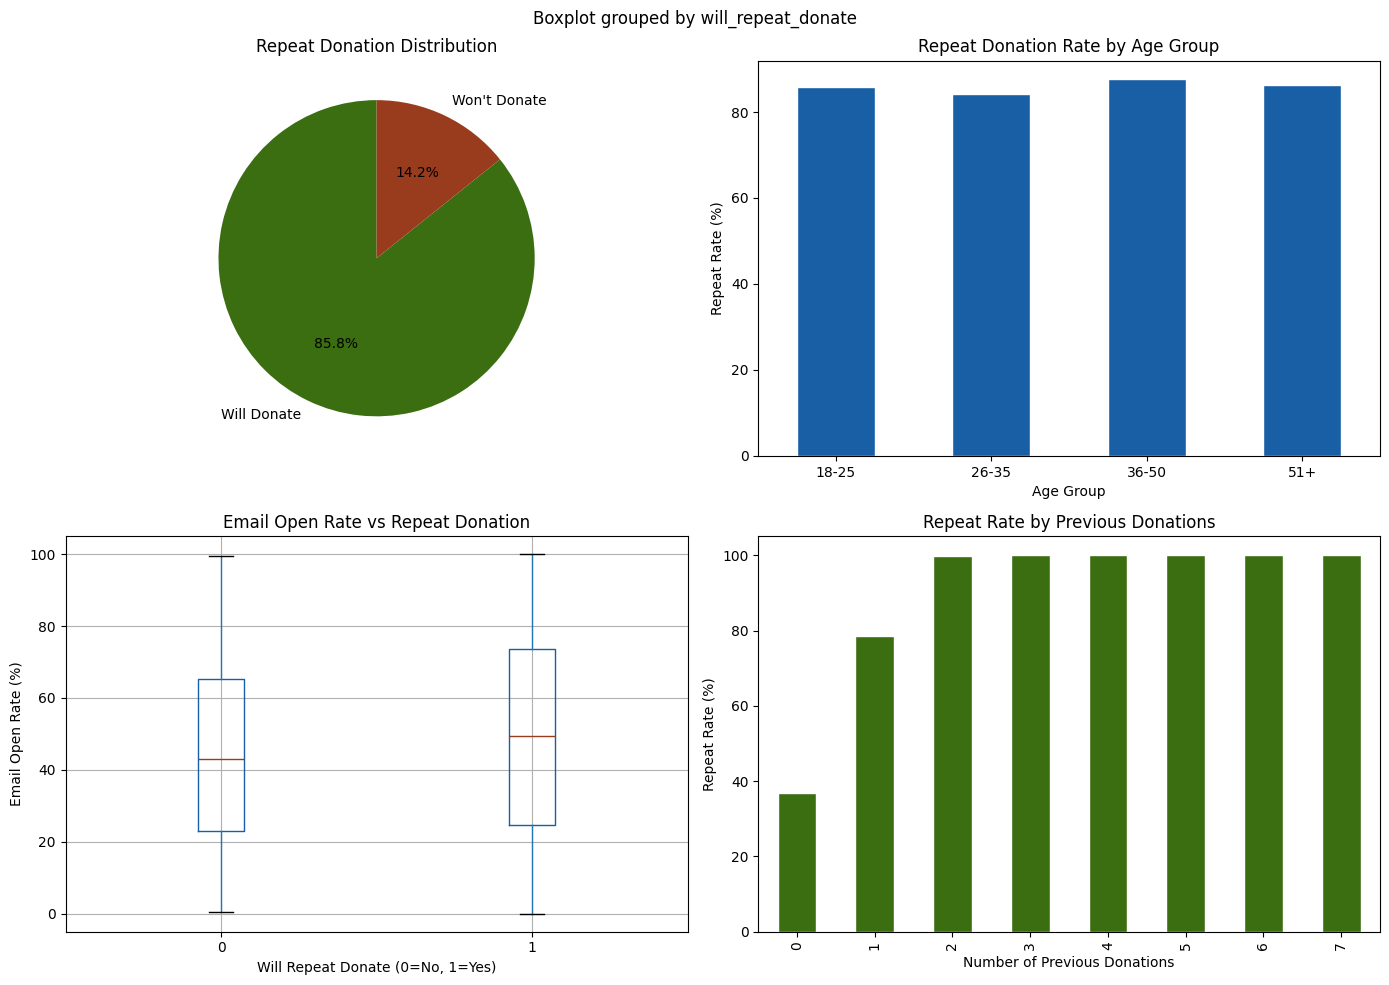

Charts saved!


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('NayePankh Foundation - Donor Data Analysis', fontsize=16, fontweight='bold')

# Plot 1 - Target distribution
axes[0,0].pie(df.will_repeat_donate.value_counts(),
              labels=['Will Donate', "Won't Donate"],
              colors=['#3B6D11', '#993C1D'],
              autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Repeat Donation Distribution')

# Plot 2 - Donations by age group
df.groupby('age_group')['will_repeat_donate'].mean().mul(100).plot(
    kind='bar', ax=axes[0,1], color='#185FA5', edgecolor='white')
axes[0,1].set_title('Repeat Donation Rate by Age Group')
axes[0,1].set_ylabel('Repeat Rate (%)')
axes[0,1].set_xlabel('Age Group')
axes[0,1].tick_params(axis='x', rotation=0)

# Plot 3 - Email open rate vs donation
df.boxplot(column='email_open_rate', by='will_repeat_donate', ax=axes[1,0],
           boxprops=dict(color='#185FA5'),
           medianprops=dict(color='#993C1D'))
axes[1,0].set_title('Email Open Rate vs Repeat Donation')
axes[1,0].set_xlabel('Will Repeat Donate (0=No, 1=Yes)')
axes[1,0].set_ylabel('Email Open Rate (%)')

# Plot 4 - Previous donations distribution
df.groupby('prev_donations')['will_repeat_donate'].mean().mul(100).plot(
    kind='bar', ax=axes[1,1], color='#3B6D11', edgecolor='white')
axes[1,1].set_title('Repeat Rate by Previous Donations')
axes[1,1].set_ylabel('Repeat Rate (%)')
axes[1,1].set_xlabel('Number of Previous Donations')

plt.tight_layout()
plt.savefig('donor_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved!")

In [6]:
# Make a copy
df_model = df.copy()

# Encode categorical columns
le = LabelEncoder()
for col in ['age_group', 'state', 'cause_area']:
    df_model[col] = le.fit_transform(df_model[col])

# Split features and target
X = df_model.drop('will_repeat_donate', axis=1)
y = df_model['will_repeat_donate']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"\nFeatures used: {list(X.columns)}")
print("\nPreprocessing done!")

Training samples: 960
Testing samples: 240

Features used: ['age_group', 'state', 'prev_donations', 'last_gift_amount', 'email_open_rate', 'campaigns_participated', 'is_social_follower', 'volunteer_history', 'cause_area']

Preprocessing done!


In [7]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False,
                              eval_metric='logloss', random_state=42)
}

# Train and evaluate
results = {}
print("Training models...\n")

for name, model in models.items():
    # Use scaled data for logistic regression
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        proba = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        proba = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, proba)

    results[name] = {
        'model': model,
        'predictions': preds,
        'accuracy': acc,
        'auc': auc
    }

    print(f"✅ {name}")
    print(f"   Accuracy: {acc*100:.1f}%  |  ROC-AUC: {auc:.3f}\n")

print("All models trained!")

Training models...

✅ Logistic Regression
   Accuracy: 94.2%  |  ROC-AUC: 0.973

✅ Decision Tree
   Accuracy: 92.5%  |  ROC-AUC: 0.910

✅ Random Forest
   Accuracy: 93.3%  |  ROC-AUC: 0.943

✅ XGBoost
   Accuracy: 92.9%  |  ROC-AUC: 0.950

All models trained!


=== Model Comparison ===
              Model  Accuracy (%)  ROC-AUC
Logistic Regression         94.17     0.97
      Decision Tree         92.50     0.91
      Random Forest         93.33     0.94
            XGBoost         92.92     0.95


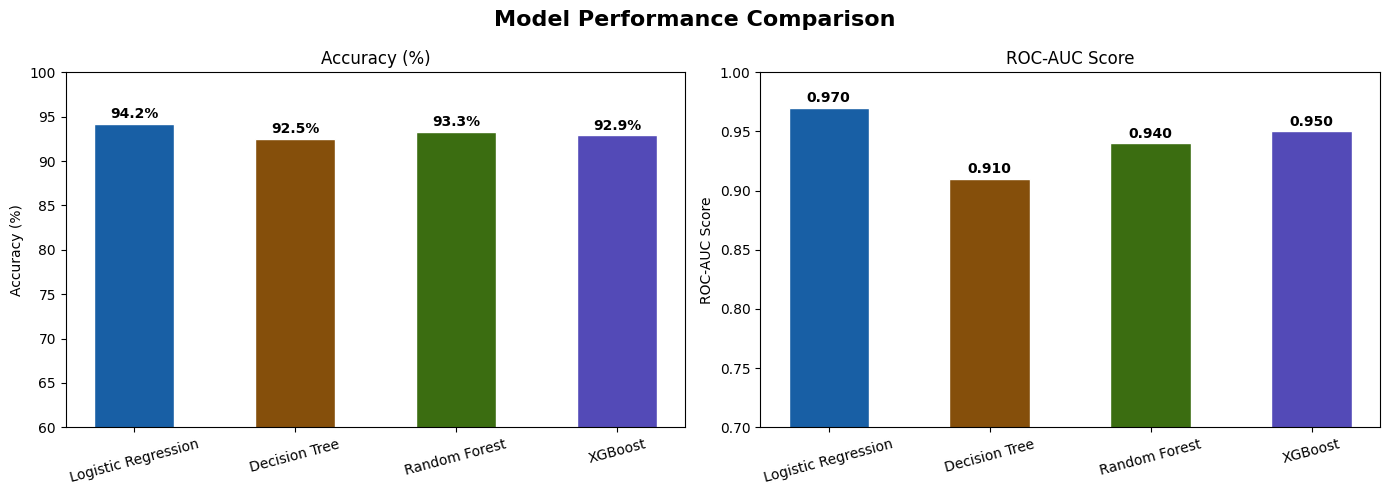

Comparison chart saved!


In [8]:
# Create comparison dataframe
comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy (%)': [results[m]['accuracy']*100 for m in results],
    'ROC-AUC': [results[m]['auc'] for m in results]
}).round(2)

print("=== Model Comparison ===")
print(comparison.to_string(index=False))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

colors = ['#185FA5', '#854F0B', '#3B6D11', '#534AB7']

# Accuracy bar chart
bars1 = axes[0].bar(comparison['Model'], comparison['Accuracy (%)'],
                     color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Accuracy (%)')
axes[0].set_ylim(60, 100)
axes[0].set_ylabel('Accuracy (%)')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars1, comparison['Accuracy (%)']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.3,
                  f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

# ROC-AUC bar chart
bars2 = axes[1].bar(comparison['Model'], comparison['ROC-AUC'],
                     color=colors, edgecolor='white', width=0.5)
axes[1].set_title('ROC-AUC Score')
axes[1].set_ylim(0.7, 1.0)
axes[1].set_ylabel('ROC-AUC Score')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, comparison['ROC-AUC']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.002,
                  f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Comparison chart saved!")

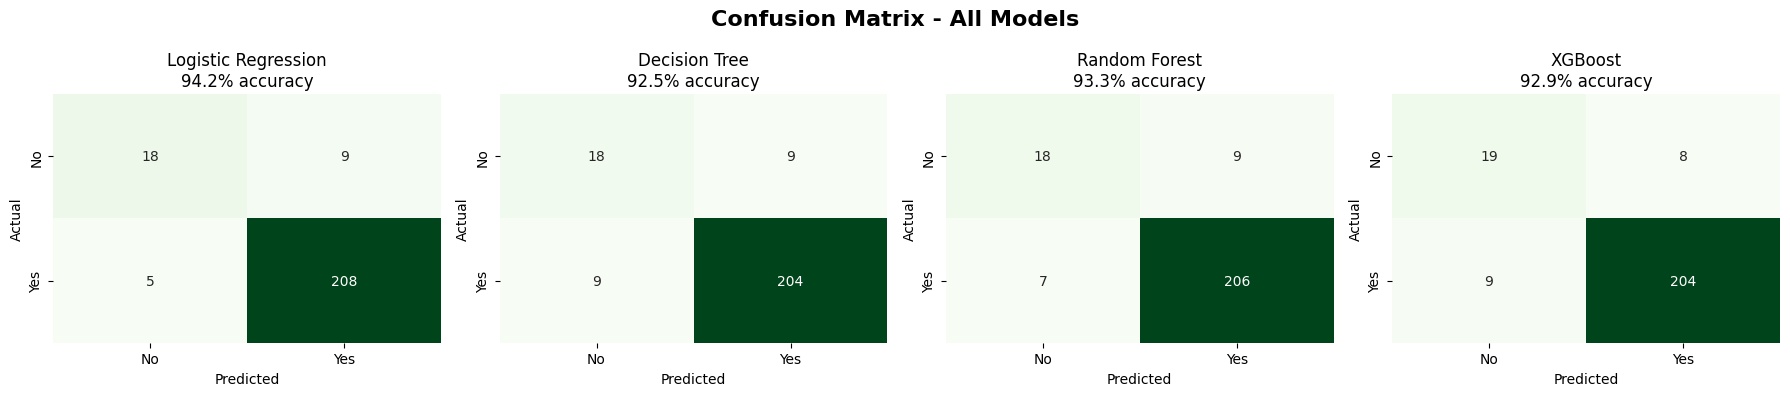

Confusion matrix saved!


In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Confusion Matrix - All Models', fontsize=16, fontweight='bold')

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['predictions'])

    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx],
                cmap='Greens', cbar=False,
                xticklabels=['No', 'Yes'],
                yticklabels=['No', 'Yes'])

    axes[idx].set_title(f'{name}\n{result["accuracy"]*100:.1f}% accuracy')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved!")

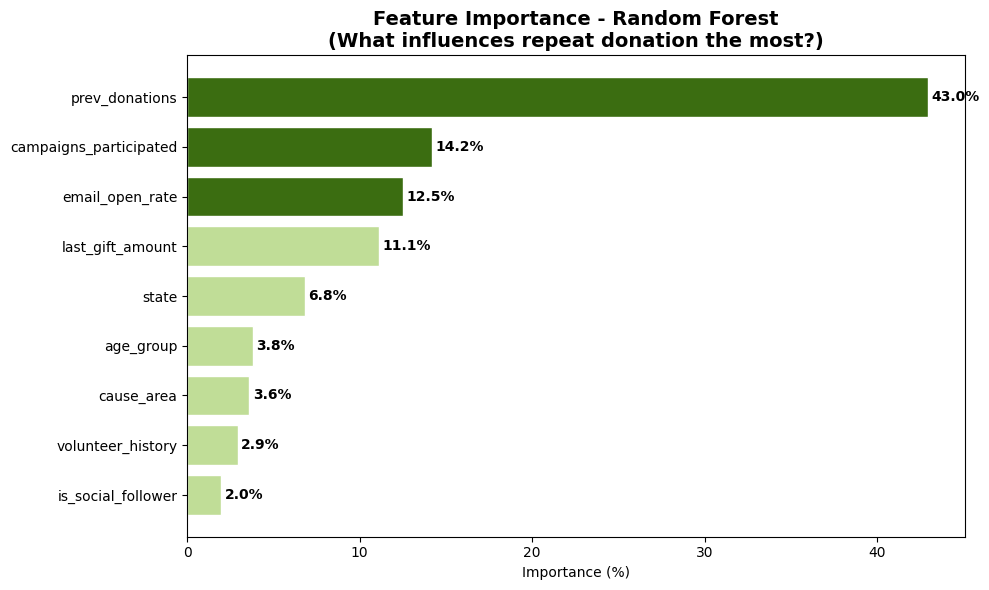


=== Top Features ===
               Feature  Importance (%)
        prev_donations       42.968125
campaigns_participated       14.195170
       email_open_rate       12.538574
      last_gift_amount       11.141442
                 state        6.832497
             age_group        3.796196
            cause_area        3.601373
     volunteer_history        2.945783
    is_social_follower        1.980840


In [10]:
# Get feature importance from Random Forest (best model)
rf_model = results['Random Forest']['model']

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance (%)': rf_model.feature_importances_ * 100
}).sort_values('Importance (%)', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

colors_imp = ['#C0DD97' if i < len(importance_df)-3
              else '#3B6D11' for i in range(len(importance_df))]

bars = ax.barh(importance_df['Feature'],
               importance_df['Importance (%)'],
               color=colors_imp, edgecolor='white')

ax.set_title('Feature Importance - Random Forest\n(What influences repeat donation the most?)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance (%)')

for bar, val in zip(bars, importance_df['Importance (%)']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Top Features ===")
print(importance_df.sort_values('Importance (%)', ascending=False).to_string(index=False))

In [11]:
def predict_donor(prev_donations, email_open_rate, campaigns_participated,
                  volunteer_history, last_gift_amount, is_social_follower,
                  age_group, state, cause_area):

    # Encode inputs manually
    age_map = {'18-25': 0, '26-35': 1, '36-50': 2, '51+': 3}
    state_map = {'DL':0,'GJ':1,'HR':2,'KA':3,'MH':4,'MP':5,'RJ':6,'TN':7,'UP':8,'WB':9}
    cause_map = {'Education':0, 'Environment':1, 'Health':2, 'Other':3}

    input_data = pd.DataFrame([{
        'age_group': age_map[age_group],
        'state': state_map[state],
        'prev_donations': prev_donations,
        'last_gift_amount': last_gift_amount,
        'email_open_rate': email_open_rate,
        'campaigns_participated': campaigns_participated,
        'is_social_follower': is_social_follower,
        'volunteer_history': volunteer_history,
        'cause_area': cause_map[cause_area],
    }])

    rf = results['Random Forest']['model']
    prediction = rf.predict(input_data)[0]
    probability = rf.predict_proba(input_data)[0][1]

    print("="*45)
    print("   NAYEPANKH DONOR PREDICTION RESULT")
    print("="*45)
    print(f"  Previous Donations:    {prev_donations}")
    print(f"  Email Open Rate:       {email_open_rate}%")
    print(f"  Campaigns Joined:      {campaigns_participated}")
    print(f"  Volunteer:             {'Yes' if volunteer_history else 'No'}")
    print(f"  Social Follower:       {'Yes' if is_social_follower else 'No'}")
    print(f"  Last Gift Amount:      ₹{last_gift_amount}")
    print("-"*45)
    print(f"  Prediction:  {'✅ WILL DONATE AGAIN' if prediction == 1 else '❌ WILL NOT DONATE AGAIN'}")
    print(f"  Confidence:  {probability*100:.1f}%")
    print("="*45)

    if prediction == 1 and probability > 0.8:
        print("  💡 Tip: High value donor! Send a")
        print("     personalised thank you message.")
    elif prediction == 1:
        print("  💡 Tip: Invite them to next campaign")
        print("     to strengthen engagement.")
    elif volunteer_history == 0:
        print("  💡 Tip: Invite them to volunteer first")
        print("     to build connection with foundation.")
    else:
        print("  💡 Tip: Try improving email engagement")
        print("     with better subject lines.")
    print("="*45)

# ── Test the predictor ──
predict_donor(
    prev_donations=3,
    email_open_rate=65,
    campaigns_participated=2,
    volunteer_history=1,
    last_gift_amount=800,
    is_social_follower=1,
    age_group='26-35',
    state='MH',
    cause_area='Education'
)

   NAYEPANKH DONOR PREDICTION RESULT
  Previous Donations:    3
  Email Open Rate:       65%
  Campaigns Joined:      2
  Volunteer:             Yes
  Social Follower:       Yes
  Last Gift Amount:      ₹800
---------------------------------------------
  Prediction:  ✅ WILL DONATE AGAIN
  Confidence:  99.0%
  💡 Tip: High value donor! Send a
     personalised thank you message.


In [12]:
print("Testing different donor profiles...\n")

# Donor 1 - High engagement
print("DONOR 1 - High Engagement Profile:")
predict_donor(5, 80, 4, 1, 1500, 1, '36-50', 'DL', 'Health')

print()

# Donor 2 - Low engagement
print("DONOR 2 - Low Engagement Profile:")
predict_donor(0, 8, 0, 0, 0, 0, '18-25', 'UP', 'Other')

print()

# Donor 3 - Medium engagement
print("DONOR 3 - Medium Engagement Profile:")
predict_donor(1, 40, 1, 0, 300, 1, '26-35', 'KA', 'Education')

Testing different donor profiles...

DONOR 1 - High Engagement Profile:
   NAYEPANKH DONOR PREDICTION RESULT
  Previous Donations:    5
  Email Open Rate:       80%
  Campaigns Joined:      4
  Volunteer:             Yes
  Social Follower:       Yes
  Last Gift Amount:      ₹1500
---------------------------------------------
  Prediction:  ✅ WILL DONATE AGAIN
  Confidence:  100.0%
  💡 Tip: High value donor! Send a
     personalised thank you message.

DONOR 2 - Low Engagement Profile:
   NAYEPANKH DONOR PREDICTION RESULT
  Previous Donations:    0
  Email Open Rate:       8%
  Campaigns Joined:      0
  Volunteer:             No
  Social Follower:       No
  Last Gift Amount:      ₹0
---------------------------------------------
  Prediction:  ❌ WILL NOT DONATE AGAIN
  Confidence:  21.0%
  💡 Tip: Invite them to volunteer first
     to build connection with foundation.

DONOR 3 - Medium Engagement Profile:
   NAYEPANKH DONOR PREDICTION RESULT
  Previous Donations:    1
  Email Open Rate

In [13]:
import pickle

# Save the Random Forest model
rf_model = results['Random Forest']['model']

with open('donor_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

print("Model saved as donor_model.pkl ✅")

# Download it to your computer
from google.colab import files
files.download('donor_model.pkl')

Model saved as donor_model.pkl ✅


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>